=== METHOD (a): Complex Integration Method (Residues) ===

1. Auxiliary function Y(z) = (X(z) / z) * z^n:


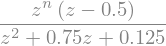


2. Poles of the function:



3. Final inverse Z-transform signal x[n] (Complex Integration):




=== METHOD (b): Partial Fraction Expansion Method ===

1. Function X(y) where y = z^(-1):


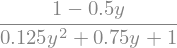


2. Partial Fraction Expansion:


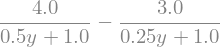


3. Final inverse Z-transform signal x[n] (Partial Fractions):


In [3]:
import sympy as sp
from IPython.display import display

# ==============================================================================
# 1. SymPy Settings and Symbol Definitions
# ==============================================================================

sp.init_printing(use_unicode=True)

z = sp.Symbol('z', complex=True)
y = sp.Symbol('y')
n = sp.Symbol('n', integer=True, nonnegative=True)


# ==============================================================================
# 2. METHOD (a): Complex Integration Method (Residue Theorem)
# ==============================================================================

print("=== METHOD (a): Complex Integration Method (Residues) ===")

X_z = (1 - 0.5 * z**(-1)) / (1 + (3/4) * z**(-1) + (1/8) * z**(-2))

# Construct Y(z) function for residue theorem: Y(z) = (X(z) / z) * z^n
Y_z = sp.simplify((X_z / z) * z**n)

print("\n1. Auxiliary function Y(z) = (X(z) / z) * z^n:")
display(Y_z)

# Find poles by solving for roots of the denominator
num_y, den_y = sp.fraction(Y_z)
poles = sp.solve(den_y, z)

print("\n2. Poles of the function:")
display(poles)

# Calculate sum of residues at the poles
res_sum = 0
for pole in poles:
    residue = sp.limit((z - pole) * Y_z, z, pole)
    res_sum += residue

x_n_method_a = sp.simplify(res_sum)

print("\n3. Final inverse Z-transform signal x[n] (Complex Integration):")
display(x_n_method_a)


# ==============================================================================
# 3. METHOD (b): Partial Fraction Expansion Method
# ==============================================================================

print("\n\n=== METHOD (b): Partial Fraction Expansion Method ===")

X_y = (1 - 0.5 * y) / (1 + (3/4) * y + (1/8) * y**2)

print("\n1. Function X(y) where y = z^(-1):")
display(X_y)

pfe_y = sp.apart(X_y, y)

print("\n2. Partial Fraction Expansion:")
display(pfe_y)

def table_lookup_inverse_z(term, y_var, n_var):
    u = sp.Heaviside(n_var)
    _, den = sp.fraction(sp.cancel(term))
    
    for base, power in sp.factor_list(den)[1]:
        roots = sp.solve(base, y_var)
        if not roots:
            continue
        
        y0 = roots[0]
        a = sp.simplify(1 / y0)
        scale = sp.simplify(-sp.Poly(base, y_var).LC() * y0)
        coeff = sp.simplify(sp.limit(term * base**power, y_var, y0) / scale**power)
        
        if power == 1:
            return sp.simplify(coeff * a**n_var * u)
            
    return term

def inverse_z_transform(expr, y_var, n_var):
    expr = sp.expand(expr)
    if isinstance(expr, sp.Add):
        return sp.simplify(sum(inverse_z_transform(t, y_var, n_var) for t in expr.args))
    return table_lookup_inverse_z(expr, y_var, n_var)

x_n_method_b = inverse_z_transform(pfe_y, y, n)

print("\n3. Final inverse Z-transform signal x[n] (Partial Fractions):")
display(x_n_method_b)